# Morphoelectric diversity quantification
The sample of 306 inhibitory neurons represents the morphoelectric diversity within a cortical column of rat vS1.


In [1]:
# Load project-specific library
import decoupling

# Load other required libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from sklearn.ensemble import RandomForestClassifier

# Define global matplotlib settings
plt.rcParams.update({
    "font.family": "Arial",
})

# Set random seed
seed = decoupling.set_seed(0)

# Set path to data
data_path = "../data/rat_bc/processed/"

Random seed 0 has been set.


In [2]:
# Read overall distribution of inhibitory neurons in an average cortical column
inh_column = pd.read_csv(
    os.path.join(data_path, "bc_distribution_inh_neurons.csv"),
)

# Set layer borders in an average cortical column
layer_labels = pd.DataFrame({
    "depth": [0.15, 0.551, 0.847, 1.342, 1.887], 
    "label": ["L1", "L2/3", "L4", "L5", "L6"],
})

# Read metadata of the sampled inhibitory neurons 
metadata = pd.read_csv(
    os.path.join(data_path, "../bc_metadata.csv"), 
    index_col="neuron_id",
)

# Read morphological features of the sampled inhibitory neurons 
morph_features = pd.read_csv(
    os.path.join(data_path, "bc_morph_features.csv"), 
    index_col="neuron_id",
)

# Read electrophysiological features of the sampled inhibitory neurons 
ephys_features = pd.read_csv(
    os.path.join(data_path, "bc_ephys_features.csv"), 
    index_col="neuron_id",
)

## Laminar distribution
Soma distribution of sampled inhibitory neurons across cortical depth consistent with the distribution of all inhibitory neuron somata in rat vS1.

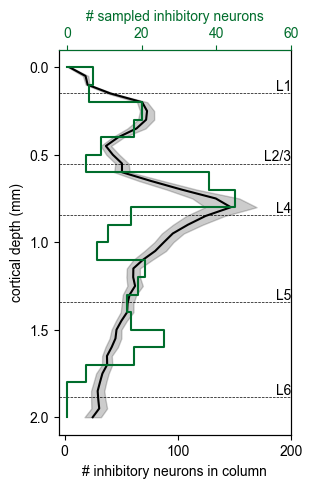

In [3]:
fig, ax = plt.subplots(figsize=(3, 5))

# ---------------------------------------------------------------------
# Plot cortical layer boundaries
# ---------------------------------------------------------------------
for _, layer in layer_labels.iterrows():
    ax.axhline(
        y=layer["depth"],
        linestyle="--",
        linewidth=0.5,
        color="black",
    )
    ax.text(
        x=200,                
        y=layer["depth"],
        s=layer["label"],
        va="bottom",
        ha="right",
    )

# ---------------------------------------------------------------------
# Plot the distribution of inhibitory neurons in a cortical column
# ---------------------------------------------------------------------
ax.fill_betweenx(
    x1=inh_column["mean"] - inh_column["ci_95"],
    x2=inh_column["mean"] + inh_column["ci_95"],
    y=inh_column["depth"],
    color="black",
    alpha=0.2,
)
ax.plot(
    inh_column["mean"],
    inh_column["depth"],
    color="black",
)

# Axis formatting
ax.invert_yaxis() # Pia at the top
ax.set_yticks(np.arange(0, 2.5, 0.5))
ax.set_xticks(np.arange(0, 300, 100))
ax.set_ylabel("cortical depth (mm)")
ax.set_xlabel("# inhibitory neurons in column")

# ---------------------------------------------------------------------
# Overlay histogram of the sampled inhibitory neurons (top x-axis)
# ---------------------------------------------------------------------
bin_width = 0.1  # 100 µm in mm
hist_counts, bin_edges = np.histogram(
    morph_features["Soma depth"],
    bins=np.arange(0, 2 + bin_width, bin_width),
)
ax_top = ax.twiny()
ax_top.step(
    x=np.r_[0, hist_counts, 0],
    y=np.r_[0, bin_edges],
    color="#006d2c",
)

# Axis formatting
ax_top.set_xticks(np.arange(0, 80, 20))
ax_top.spines["top"].set_color("#006d2c")
ax_top.tick_params(axis="x", colors="#006d2c")
ax_top.set_xlabel("# sampled inhibitory neurons", color="#006d2c")

# ---------------------------------------------------------------------
plt.show()


## Consensus clustering using me-features

* Descriptive features are calculated from a given morphology and voltage trace. 
* A preliminary clustering step dependent on the data modality is followed by a reduction of the number of clusters using an entropy criterion.
* Cluster stability is evaluated by resampling the data and unstable clusters are merged using an
entropy criterion. 

In [ ]:
# Set low variability threshold
low_var_thresh = 0.25

# Set high correlation threshold
corr_thresh = 0.95

# Perform consensus clustering using morphoelectric features
model = decoupling.ConsensusClustering()
model.fit(
    Morph=morph_features, 
    Ephys=ephys_features,
    low_var_thresh=low_var_thresh, 
    corr_thresh=corr_thresh,
)

# Obtain optimal weight between morph and ephys
weight = model.optimal_weight_

# Get morphoelectric clusters
labels = model.labels_

**Note:** The analysis results in the manuscript used now-legacy releases of NumPy, SciPy, and scikit-learn. Differences may be caused by:

1. Changes in NumPy's random number generation and floating-point handling.
2. Minor differences in scikit-learn estimators (e.g., GMM, Spectral Biclustering) that rely on internal randomness.
3. Tie-breaking behavior in hierarchical clustering algorithms, which may change across NumPy and SciPy versions.

For exact replication of legacy results, the original versions of NumPy (1.22.4), SciPy (1.9.3), and scikit-learn (1.1.2) would be required.

## Robustness of cluster assignments
* Evaluation of cluster predictability using 5-fold cross-validation. 
* Each data modality was assessed independently.
* Seven classifiers were used.

In [6]:
# Preprocess morphological features by selecting relevant features and z-scoring
M = decoupling.preprocess_features(
    Features=morph_features, 
    low_var_thresh=low_var_thresh, 
    corr_thresh=corr_thresh,
)

# Normalize electrophysiological sparse principal components
E = decoupling.preprocess_features(
    Features=ephys_features,  
    low_var_thresh=None, 
    corr_thresh=None,
)

# Preprocess morphoelectric features using optimal weight
X = decoupling.align_and_preprocess_features(
    Morph=morph_features, 
    Ephys=ephys_features, 
    weight=weight, 
    low_var_thresh=low_var_thresh, 
    corr_thresh=corr_thresh,
)

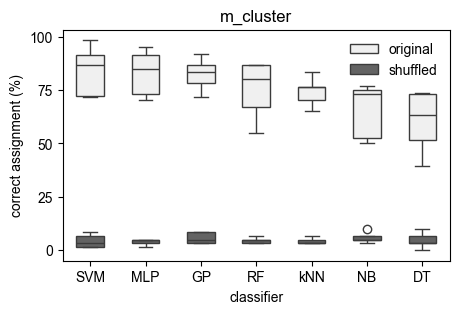

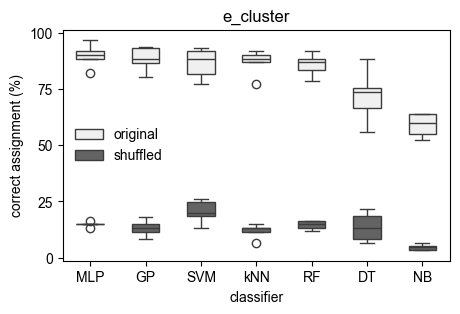

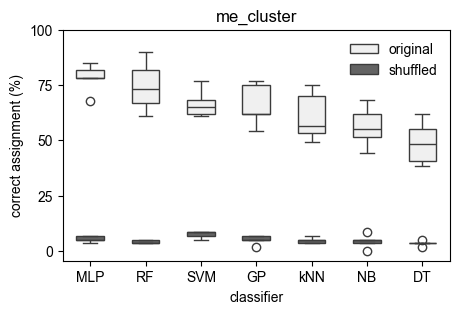

In [7]:
for feat, typ in zip([M, E, X], ["m_cluster", "e_cluster", "me_cluster"]):

    # Select data modality
    target = metadata[typ].dropna()
    features = feat.loc[target.index]
    
    # Compute cluster predictability using default classifiers
    scores = decoupling.cluster_predictability(
        X=features, 
        y=target, 
        k=5,
        shuffle=True, 
        random_state=seed,
    )
    
    # Scores formatting
    scores["accuracy"] *= 100
    scores["classifier"] = (
        scores["classifier"]
        .replace({
            "GaussianProcessClassifier": "GP",
            "DecisionTreeClassifier": "DT",
            "RandomForestClassifier": "RF",
            "KNeighborsClassifier": "kNN",
            "MLPClassifier": "MLP",
            "GaussianNB": "NB",
            "SVC": "SVM",
        })
    )

    # Plot results
    fig, ax = plt.subplots(figsize=(5, 3))

    sns.boxplot(
        data=scores, 
        x="classifier", 
        y="accuracy", 
        hue="class_labels", 
        palette={"original": "#f0f0f0", "shuffled": "#636363"}, 
        dodge=False, 
        linewidth=1, 
        width=0.5, 
        ax=ax,
    )

    # Axis formatting
    ax.set_title(typ)
    ax.set_yticks(np.arange(0, 125, 25)) 
    ax.set_ylabel("correct assignment (%)")
    ax.legend(loc="best", frameon=False, ncol=1, title="")

    plt.show()

## Feature importance for class assignments
Calculation of the Gini impurity index of m- and e-features that were used to determine m- and e-clusters.

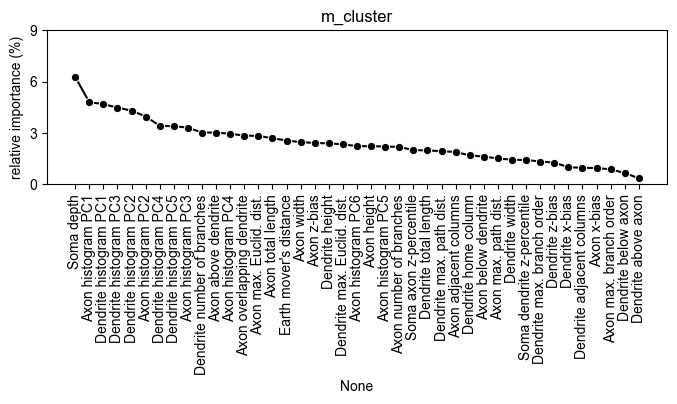

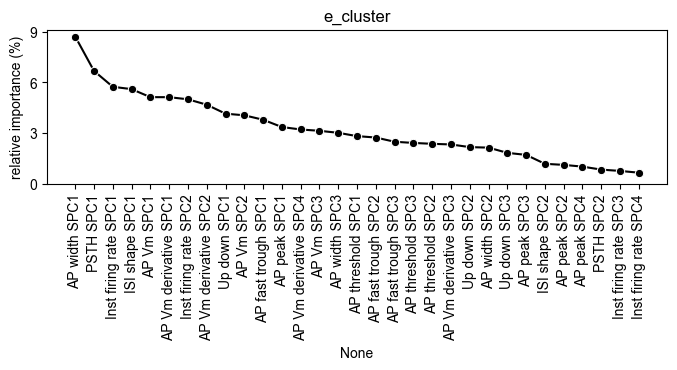

In [8]:
for feat, typ in zip([M, E], ["m_cluster", "e_cluster"]):

    # Select data modality
    target = metadata[typ].dropna()
    features = feat.loc[target.index]

    # Random Forest Classifier
    rf_clf = RandomForestClassifier(
        n_estimators=500,
        criterion="gini",  
        oob_score=True, 
        random_state=seed,
    )

    # Fit model for feature importance
    rf_clf.fit(features, target)

    feature_importance = (
        pd.DataFrame(
            100*rf_clf.feature_importances_, 
            columns=["relative importance (%)"], 
            index=features.columns,
        )
        .sort_values(
            by=["relative importance (%)"], 
            ascending=False
        )
    )

    # Plot results
    fig, ax = plt.subplots(figsize=(8, 2))
 
    sns.lineplot(
        data=feature_importance, 
        x=feature_importance.index, 
        y="relative importance (%)", 
        color="black", 
        marker="o", 
        sort=False, 
        ax=ax,
    )

    # Axis formatting
    ax.set_title(typ)
    ax.set_yticks(np.arange(0, 12, 3)) 
    plt.xticks(rotation=90)

    plt.show()

## Sample variability assessment
For both m- and e- features, the proportion of explained variance saturates at sample sizes smaller than this dataset, as determined through multiple shuffled subsampling analyses.

In [9]:
# Set sample sizes to be considered
sample_sizes = np.concatenate([
    np.arange( 2,  10,  2), 
    np.arange(10,  50, 10), 
    np.arange(50, 350, 50) - 1,
])

# Set number of principal components
n_components = 1 

# Set number of shufles when drawing the sample
n_shuffles = 100

# Compute proportion of explained variance for morphological features
pev_morph = decoupling.variance_per_sample_size(
    X=morph_features, 
    sample_sizes=sample_sizes, 
    n_components=n_components, 
    n_shuffles=n_shuffles,
)

# Compute proportion of explained variance for electrophysiological features
pev_ephys = decoupling.variance_per_sample_size(
    X=ephys_features, 
    sample_sizes=sample_sizes, 
    n_components=n_components, 
    n_shuffles=n_shuffles,
)

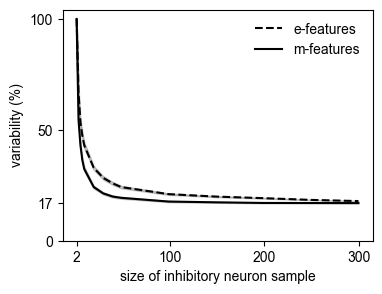

In [10]:
fig, ax = plt.subplots(figsize=(4, 3))

# Set style
linestyle = {"morph": "-", "ephys": "--"}
label_mapping = {"morph": "m-features", "ephys": "e-features"}

# Plot results
for (df, typ) in zip([pev_ephys, pev_morph], ["ephys", "morph"]):
    ax.fill_between(
        x=df["sample_size"], 
        y1=df["mean"] - df["ci_95"],
        y2=df["mean"] + df["ci_95"],
        color="black",
        alpha=0.2,
    )
    ax.plot(
        df["sample_size"], 
        df["mean"],
        color="black", 
        linestyle=linestyle[typ], 
        label=label_mapping[typ],
    )

# Axis formatting
ax.set_yticks([0,  17,  50, 100])
ax.set_xticks([2, 100, 200, 300])
ax.set_ylabel("variability (%)")
ax.set_xlabel("size of inhibitory neuron sample")
ax.legend(loc="upper right", frameon=False, ncol=1, title="")

plt.show()